In [1]:
# Cell 1 — Setup + Diagnostic
from google.cloud import bigquery
import pandas as pd

PROJECT_ID = "fyxical-poc"
DATASET = "fyxical_poc"

client = bigquery.Client(project=PROJECT_ID)

# Diagnostic
print("1. Testing connection...")
test = client.query("SELECT 1 as test").to_dataframe()
print(f"✅ Connection OK: {test}")

print("\n2. Listing datasets...")
for ds in client.list_datasets():
    print(f"   📁 {ds.dataset_id}")

print("\n3. Listing tables in fyxical_poc...")
for table in client.list_tables(DATASET):
    print(f"   📋 {table.table_id}")

1. Testing connection...
✅ Connection OK:    test
0     1

2. Listing datasets...
   📁 fyxical_poc

3. Listing tables in fyxical_poc...
   📋 ml_predictions
   📋 patient_intake
   📋 patient_pathways


In [2]:
# 04 - Logistic Regression Model + Deployment

from google.cloud import bigquery
import pandas as pd
import joblib
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score, RocCurveDisplay)
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ID = "fyxical-poc"
DATASET = "fyxical_poc"
client = bigquery.Client(project=PROJECT_ID)

patients = client.query(f"""
    SELECT p.*, pw.recommended_pathway
    FROM `{PROJECT_ID}.{DATASET}.patient_intake` p
    JOIN `{PROJECT_ID}.{DATASET}.patient_pathways` pw
    USING (patient_id)
""").to_dataframe()

print(f"✅ {len(patients)} patients loaded with pathways")

✅ 500 patients loaded with pathways


In [3]:
# Features selected based on clinical availability at intake
# osw_baseline_raw_score excluded — mathematically derived from
# osw_baseline_percent_disability (would introduce redundancy)
features = [
    'age',
    'pain_severity_score_0_10',
    'pain_duration_weeks',
    'osw_baseline_percent_disability',
    'work_related_injury'
]

# Encode work_related_injury if stored as string
X = patients[features].copy()
if X['work_related_injury'].dtype == object:
    X['work_related_injury'] = X['work_related_injury'].map(
        {'Yes': 1, 'No': 0, 'yes': 1, 'no': 0, True: 1, False: 0}
    ).fillna(0)

X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# Encode target — recommended_pathway is NOT derived from any feature in X
le = LabelEncoder()
y = le.fit_transform(patients['recommended_pathway'])

print("Pathway classes (target variable):")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

print(f"\n✅ Features : {features}")
print(f"✅ Shape    : {X.shape}")
print(f"✅ Classes  : {len(le.classes_)}")

Pathway classes (target variable):
  0 → Home Exercise Program
  1 → In-Clinic Progression
  2 → Long-term Management + Referral
  3 → Standard Progression

✅ Features : ['age', 'pain_severity_score_0_10', 'pain_duration_weeks', 'osw_baseline_percent_disability', 'work_related_injury']
✅ Shape    : (500, 5)
✅ Classes  : 4


In [4]:
# Stratified split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {len(X_train)} patients (80%)")
print(f"Test set     : {len(X_test)} patients (20%)")
print(f"\nClass distribution — Training set:")
train_dist = pd.Series(y_train).map(dict(enumerate(le.classes_))).value_counts()
print(train_dist)

Training set : 400 patients (80%)
Test set     : 100 patients (20%)

Class distribution — Training set:
Standard Progression               186
Long-term Management + Referral    101
In-Clinic Progression               57
Home Exercise Program               56
Name: count, dtype: int64


In [5]:
# Fit scaler on training set only — transform test set separately

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("✅ Model trained on training set only (no leakage)")
print(f"   Iterations used: {model.n_iter_[0]}")

✅ Model trained on training set only (no leakage)
   Iterations used: 26


In [6]:
 y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"=== TEST SET PERFORMANCE ===")
print(f"Accuracy: {accuracy:.2%}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

=== TEST SET PERFORMANCE ===
Accuracy: 83.00%

Classification Report:
                                 precision    recall  f1-score   support

          Home Exercise Program       0.78      1.00      0.88        14
          In-Clinic Progression       0.67      1.00      0.80        14
Long-term Management + Referral       0.88      0.88      0.88        25
           Standard Progression       0.92      0.70      0.80        47

                       accuracy                           0.83       100
                      macro avg       0.81      0.90      0.84       100
                   weighted avg       0.85      0.83      0.83       100



Macro AUC (One-vs-Rest): 0.9431

Per-Class AUC:
  Home Exercise Program               AUC: 0.977
  In-Clinic Progression               AUC: 0.951
  Long-term Management + Referral     AUC: 0.985
  Standard Progression                AUC: 0.860


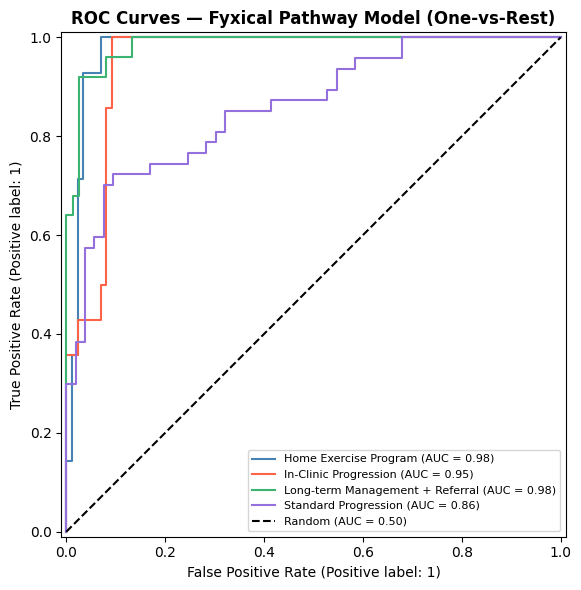

✅ Saved: roc_curves.png


In [8]:
y_test_bin = label_binarize(y_test, classes=list(range(len(le.classes_))))
y_prob     = model.predict_proba(X_test_scaled)

macro_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='macro')
print(f"Macro AUC (One-vs-Rest): {macro_auc:.4f}")

print("\nPer-Class AUC:")
for i, cls in enumerate(le.classes_):
    cls_auc = roc_auc_score(y_test_bin[:, i], y_prob[:, i])
    print(f"  {cls:<35} AUC: {cls_auc:.3f}")

# ROC Plot
colors = ['steelblue', 'tomato', 'mediumseagreen', 'mediumpurple', 'darkorange']
fig, ax = plt.subplots(figsize=(9, 6))
for i, (cls, color) in enumerate(zip(le.classes_, colors)):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i], y_prob[:, i],
        name=cls,
        curve_kwargs={"color": color},  # updated syntax
        ax=ax
    )
ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
ax.set_title('ROC Curves — Fyxical Pathway Model (One-vs-Rest)',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: roc_curves.png")

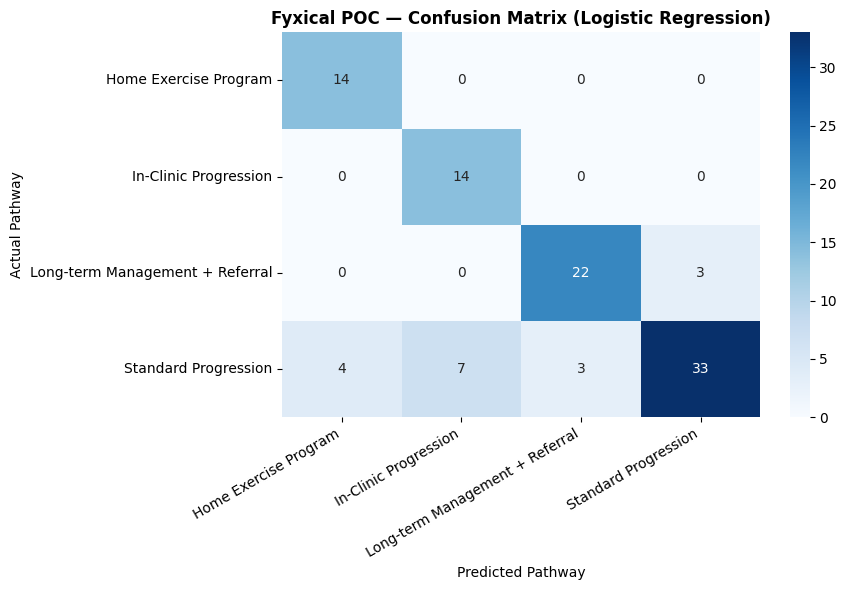

✅ Saved: confusion_matrix.png


In [9]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_, ax=ax)
ax.set_title('Fyxical POC — Confusion Matrix (Logistic Regression)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Actual Pathway')
ax.set_xlabel('Predicted Pathway')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: confusion_matrix.png")

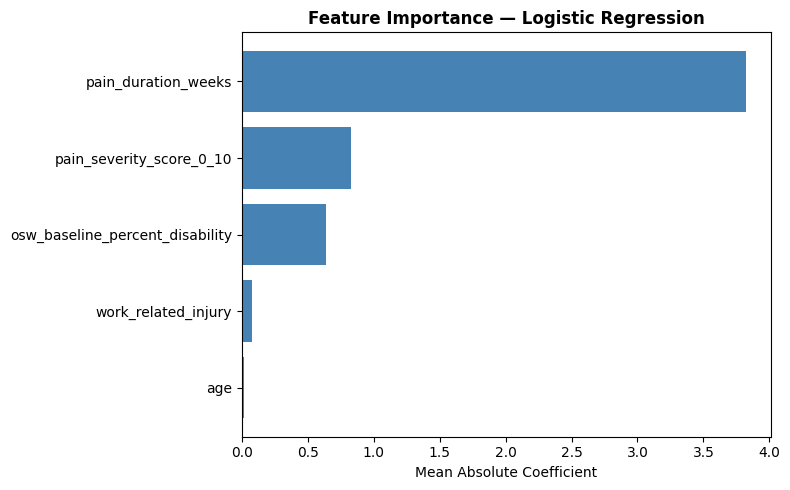

✅ Saved: feature_importance.png


In [10]:
importance_df = pd.DataFrame({
    'feature'   : features,
    'importance': abs(model.coef_).mean(axis=0)
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
ax.set_title('Feature Importance — Logistic Regression',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Mean Absolute Coefficient')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: feature_importance.png")

In [11]:
joblib.dump(model,  'fyxical_pathway_model.pkl')
joblib.dump(scaler, 'fyxical_scaler.pkl')
joblib.dump(le,     'fyxical_label_encoder.pkl')

print("✅ fyxical_pathway_model.pkl")
print("✅ fyxical_scaler.pkl")
print("✅ fyxical_label_encoder.pkl")

✅ fyxical_pathway_model.pkl
✅ fyxical_scaler.pkl
✅ fyxical_label_encoder.pkl


In [12]:
loaded_model  = joblib.load('fyxical_pathway_model.pkl')
loaded_scaler = joblib.load('fyxical_scaler.pkl')
loaded_le     = joblib.load('fyxical_label_encoder.pkl')

new_patient = pd.DataFrame([{
    'age'                          : 45,
    'pain_severity_score_0_10'     : 7,
    'pain_duration_weeks'          : 6,
    'osw_baseline_percent_disability': 42,
    'work_related_injury'          : 1
}])

new_scaled  = loaded_scaler.transform(new_patient)
prediction  = loaded_model.predict(new_scaled)
probability = loaded_model.predict_proba(new_scaled)

print("=== CLINICAL PREDICTION DEMO ===")
print("Patient: Age 45 | Severity 7/10 | 6 weeks | OSW 42% | Work injury")
print(f"\nRecommended Pathway: {loaded_le.inverse_transform(prediction)[0]}")
print(f"\nConfidence by Pathway:")
for cls, prob in zip(loaded_le.classes_, probability[0]):
    bar = '█' * int(prob * 30)
    print(f"  {cls:<35} {prob:.1%} {bar}")

=== CLINICAL PREDICTION DEMO ===
Patient: Age 45 | Severity 7/10 | 6 weeks | OSW 42% | Work injury

Recommended Pathway: Standard Progression

Confidence by Pathway:
  Home Exercise Program               4.7% █
  In-Clinic Progression               23.1% ██████
  Long-term Management + Referral     4.5% █
  Standard Progression                67.7% ████████████████████


In [13]:
predictions_df = X_test.copy().reset_index(drop=True)
predictions_df['actual_pathway']    = le.inverse_transform(y_test)
predictions_df['predicted_pathway'] = le.inverse_transform(y_pred)
predictions_df['correct']           = (predictions_df['actual_pathway'] ==
                                        predictions_df['predicted_pathway'])

job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE",
    autodetect=True
)
job = client.load_table_from_dataframe(
    predictions_df,
    f'{PROJECT_ID}.{DATASET}.ml_predictions',
    job_config=job_config
)
job.result()

print(f"✅ {len(predictions_df)} predictions saved to BigQuery!")
print(f"   Table : {PROJECT_ID}.{DATASET}.ml_predictions")
print(f"   Accuracy : {predictions_df['correct'].mean():.2%}")

✅ 100 predictions saved to BigQuery!
   Table : fyxical-poc.fyxical_poc.ml_predictions
   Accuracy : 83.00%
